<a href="https://www.kaggle.com/code/maximendacleu/youtube-video-analytics?scriptVersionId=290139602" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

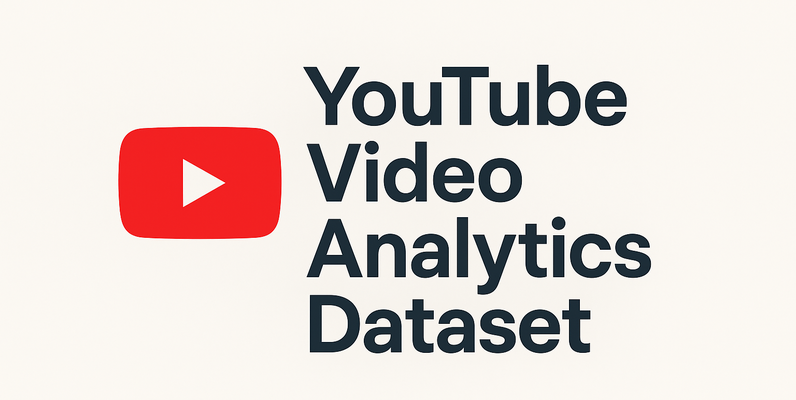

# YouTube Video Performance Analysis

## Objective
The goal of this notebook is to perform a comprehensive analysis of YouTube video performance. We will examine various factors contributing to virality, viewer engagement, and content strategy. Additionally, we will build machine learning models to predict video performance and classify videos based on their success metrics.

## Dataset
The analysis uses `/kaggle/input/youtube-analytics-data/youtube_recommendation_dataset -.csv`, which contains metrics such as view count, like count, comment count, duration, and publication time.

In [3]:
# Importing the necessary libraries
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Data Loading and Preprocessing

First, we load the dataset and inspect its structure. We will also perform necessary cleaning steps, such as handling missing values and converting data types.

In [4]:
# Load the dataset
file_path = '/kaggle/input/youtube-analytics-data/youtube_recommendation_dataset -.csv'
df = pd.read_csv(file_path)

# Display the first few rows
df.head()

,Title,channel_title,published_at,category_id,view_count,like_count,comment_count,favorite_count,duration,definition,caption,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days
0,LA PERVERSA X LA INSUPERABLE X ALOFOKE MUSIC X...,AlofokeMusicSounds,2025-11-16 15:34:55+00:00,10,1405647,140463,9063,0,PT1M51S,hd,False,0.106375,0.099928,0.006448,111,1
1,Moana | Official Teaser,Disney,2025-11-17 17:00:47+00:00,24,2776847,26801,6684,0,PT1M,hd,True,0.012059,0.009652,0.002407,60,0
2,$0 - $1 Trillion Only FISHING in Steal a Brain...,CaylusBlox,2025-11-17 22:57:14+00:00,20,1189857,16174,1827,0,PT18M2S,hd,False,0.015129,0.013593,0.001535,1082,0
3,ALLDAY PROJECT - ‘ONE MORE TIME’ M/V,THEBLACKLABEL,2025-11-17 09:00:07+00:00,10,5319161,0,12869,0,PT3M23S,hd,True,0.002419,0.000000,0.002419,203,1
4,La Lupa | Vendetta Hero Trailer | Overwatch 2,PlayOverwatch,2025-11-17 17:00:06+00:00,20,597542,41742,4728,0,PT3M35S,hd,True,0.077768,0.069856,0.007912,215,0


In [5]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537 entries, 0 to 536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Title                    537 non-null    object 
 1   channel_title            537 non-null    object 
 2   published_at             537 non-null    object 
 3   category_id              537 non-null    int64  
 4   view_count               537 non-null    int64  
 5   like_count               537 non-null    int64  
 6   comment_count            537 non-null    int64  
 7   favorite_count           537 non-null    int64  
 8   duration                 537 non-null    object 
 9   definition               537 non-null    object 
 10  caption                  537 non-null    bool   
 11  engagement_rate          537 non-null    float64
 12  likes_to_views_ratio     537 non-null    float64
 13  comments_to_views_ratio  537 non-null    float64
 14  duration_seconds         5

### Feature Engineering

We need to convert the `published_at` column to datetime objects to extract useful temporal features like the hour and day of publication. We will also ensure that the `duration` is in a usable format (seconds).

In [6]:
# Convert 'published_at' to datetime
df['published_at'] = pd.to_datetime(df['published_at'])

# Extract temporal features
df['publish_year'] = df['published_at'].dt.year
df['publish_month'] = df['published_at'].dt.month
df['publish_day'] = df['published_at'].dt.day_name()
df['publish_hour'] = df['published_at'].dt.hour

# Calculate video age in days
reference_date = df['published_at'].max()
df['video_age_days'] = (reference_date - df['published_at']).dt.days

# Ensure 'duration_seconds' is numeric
print(df[['duration', 'duration_seconds']].head())

  duration  duration_seconds
0  PT1M51S               111
1     PT1M                60
2  PT18M2S              1082
3  PT3M23S               203
4  PT3M35S               215


## 2. Exploratory Data Analysis (EDA)

In this section, we will visualize the distributions of key metrics and explore relationships between them.

In [7]:
# Summary statistics
df.describe()

,category_id,view_count,like_count,comment_count,favorite_count,engagement_rate,likes_to_views_ratio,comments_to_views_ratio,duration_seconds,video_age_days,publish_year,publish_month,publish_hour
count,537.000000,5.370000e+02,5.370000e+02,537.000000,537.0,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000,537.000000
mean,22.456238,2.145752e+07,4.336044e+05,7125.700186,0.0,0.028722,0.027692,0.001030,4802.746741,934.001862,2022.789572,6.914339,12.666667
std,5.854776,4.015200e+07,8.386711e+05,36075.115032,0.0,0.020608,0.019708,0.002166,13748.249437,904.534488,2.465138,3.450627,5.407177
min,1.000000,0.000000e+00,0.000000e+00,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,2012.000000,1.000000,0.000000
25%,20.000000,2.676921e+06,5.559100e+04,1018.000000,0.0,0.015579,0.015301,0.000115,52.000000,261.000000,2022.000000,4.000000,10.000000
50%,24.000000,6.385911e+06,1.550550e+05,2354.000000,0.0,0.024368,0.023565,0.000398,390.000000,658.000000,2024.000000,7.000000,14.000000
75%,27.000000,2.270604e+07,4.631890e+05,5925.000000,0.0,0.037366,0.036282,0.000954,1639.000000,1363.000000,2025.000000,10.000000,16.000000
max,28.000000,3.697310e+08,1.087934e+07,810641.000000,0.0,0.215744,0.199095,0.026031,105227.000000,4772.000000,2025.000000,12.000000,23.000000


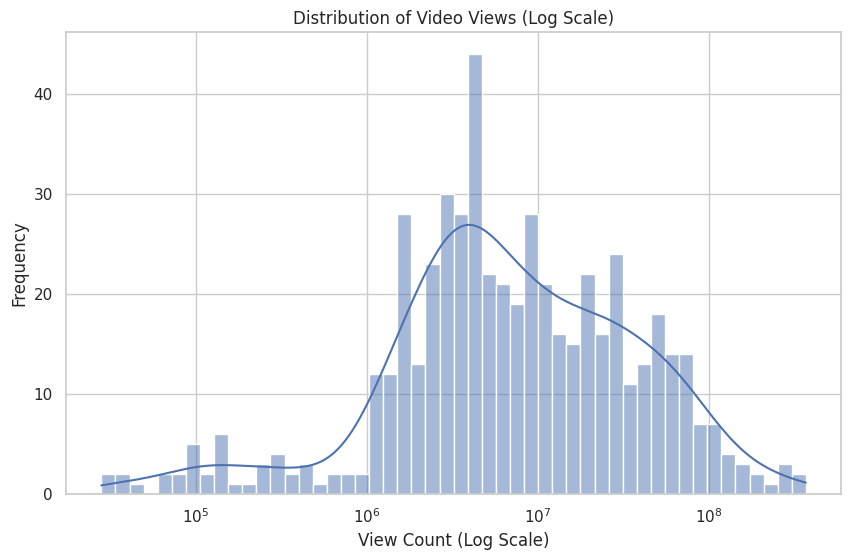

In [8]:
# Distribution of Views
plt.figure(figsize=(10, 6))
# Filter out 0 values for log scale to avoid errors
sns.histplot(df[df['view_count'] > 0]['view_count'], bins=50, kde=True, log_scale=True)
plt.title('Distribution of Video Views (Log Scale)')
plt.xlabel('View Count (Log Scale)')
plt.ylabel('Frequency')
plt.show()

***Interpretation:*** The distribution of views is likely highly skewed, with a few videos getting massive views while the majority get fewer. Using a log scale helps visualize this spread.

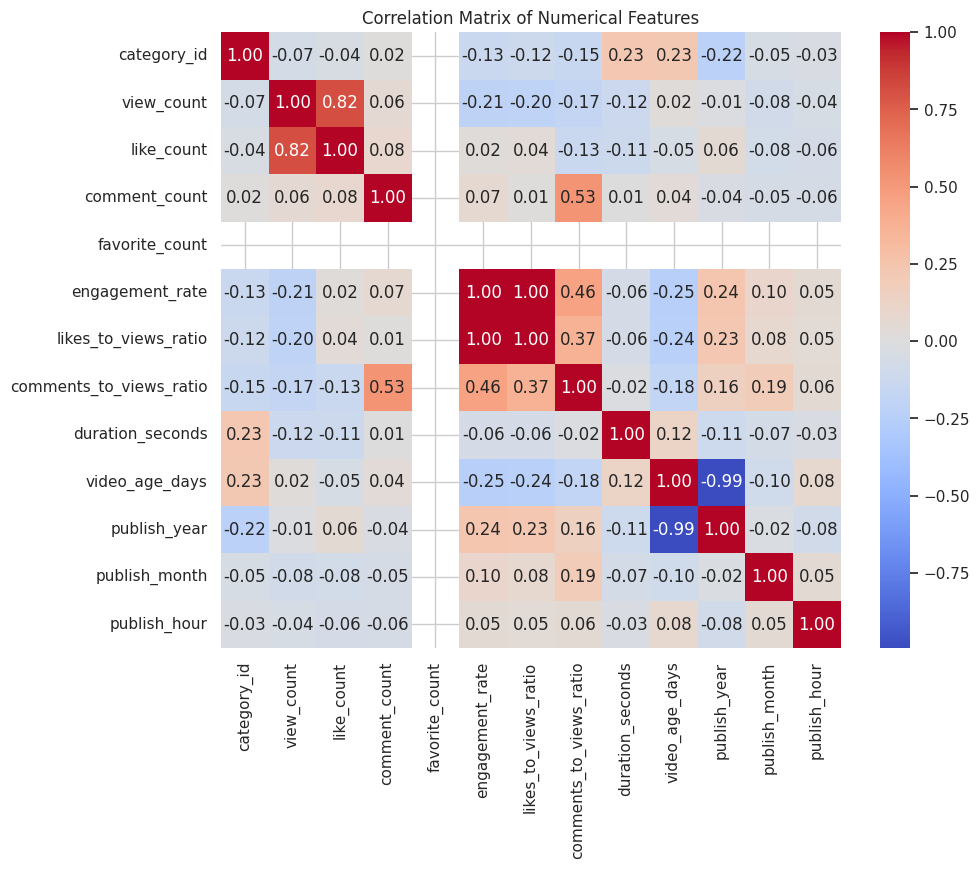

In [9]:
# Correlation Matrix
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

***Interpretation:*** We look for strong positive correlations (red) between `view_count`  and other metrics like `like_count` or `comment_count`. For example, the more views a video has, the more likes it will generate. Similarly, the engagement rate depends on the number of likes and comments. However, older videos (`video_age_days` and `publish_year`) struggle to reach the desired performance levels unless they have generated a high engagement rate.

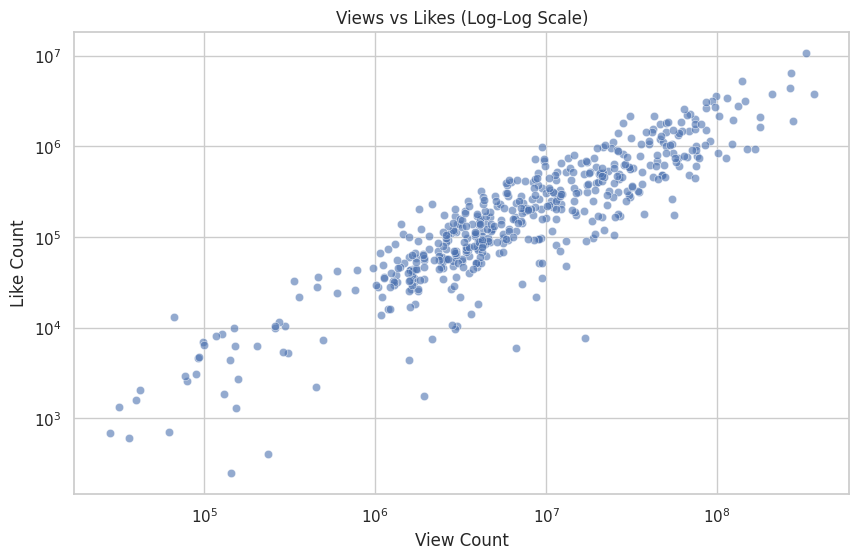

In [10]:
# Views vs Likes Scatter Plot
plt.figure(figsize=(10, 6))
# Filter out 0 values for log scale
plot_df = df[(df['view_count'] > 0) & (df['like_count'] > 0)]
sns.scatterplot(data=plot_df, x='view_count', y='like_count', alpha=0.6)
plt.xscale('log')
plt.yscale('log')
plt.title('Views vs Likes (Log-Log Scale)')
plt.xlabel('View Count')
plt.ylabel('Like Count')
plt.show()

***Interpretation:*** A strong linear relationship in log-log scale indicates that likes grow proportionally with views.

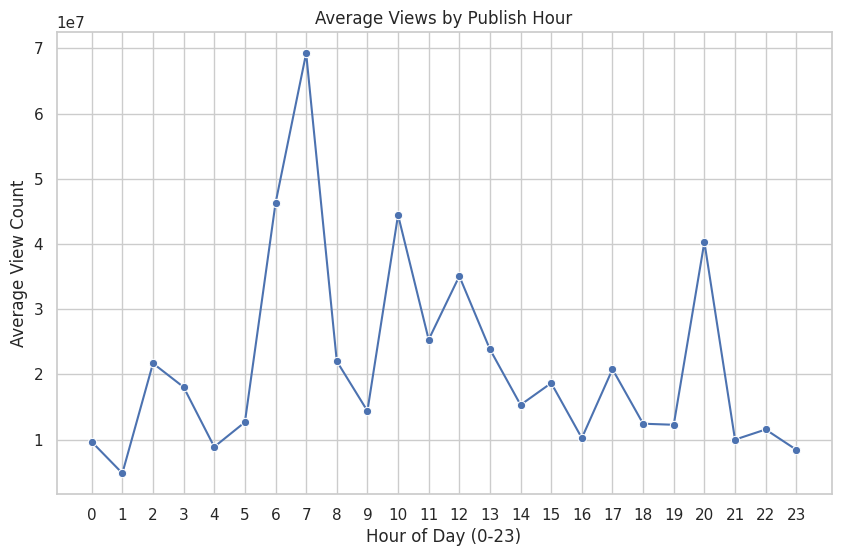

In [11]:
# Average Views by Publish Hour
hourly_views = df.groupby('publish_hour')['view_count'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=hourly_views, x='publish_hour', y='view_count', marker='o')
plt.title('Average Views by Publish Hour')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average View Count')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

***Interpretation:*** This plot reveals the best time of day to publish videos to maximize views. This means that videos published at 7 a.m. generally receive a large number of views. Conversely, those posted later in the day (from 9 p.m. to 1 a.m.) are likely to be ignored by users.

## 3. Viewer Engagement Behavior

We analyze how viewers engage with content by looking at the `engagement_rate` and `likes_to_views_ratio`.

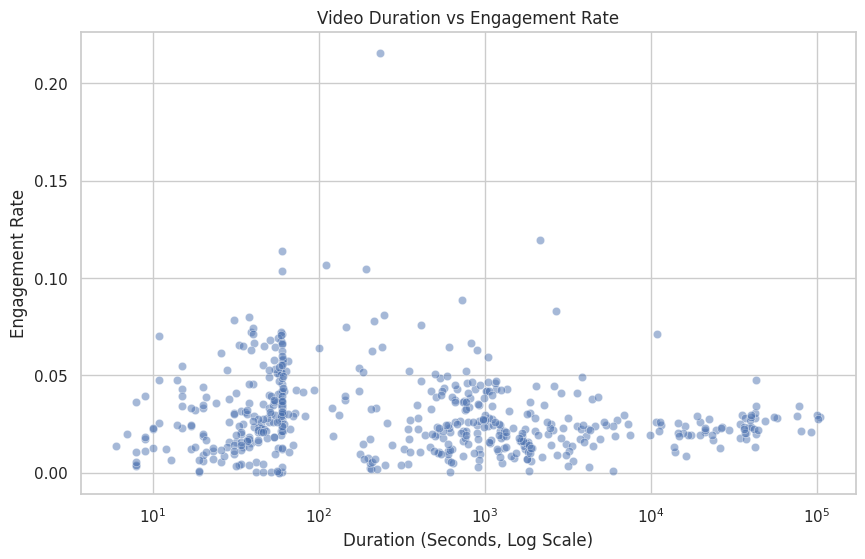

In [12]:
# Duration vs Engagement Rate
plt.figure(figsize=(10, 6))
# Filter out 0 values for log scale
plot_df = df[df['duration_seconds'] > 0]
sns.scatterplot(data=plot_df, x='duration_seconds', y='engagement_rate', alpha=0.5)
plt.xscale('log')
plt.title('Video Duration vs Engagement Rate')
plt.xlabel('Duration (Seconds, Log Scale)')
plt.ylabel('Engagement Rate')
plt.show()

***Interpretation:*** Shorter videos often have higher engagement rates as they are easier to consume fully.

## 4. Predict Video Performance

We will attempt to predict `view_count` using other available features.

Root Mean Squared Error (Log Scale): 0.9543
R2 Score: 0.6954


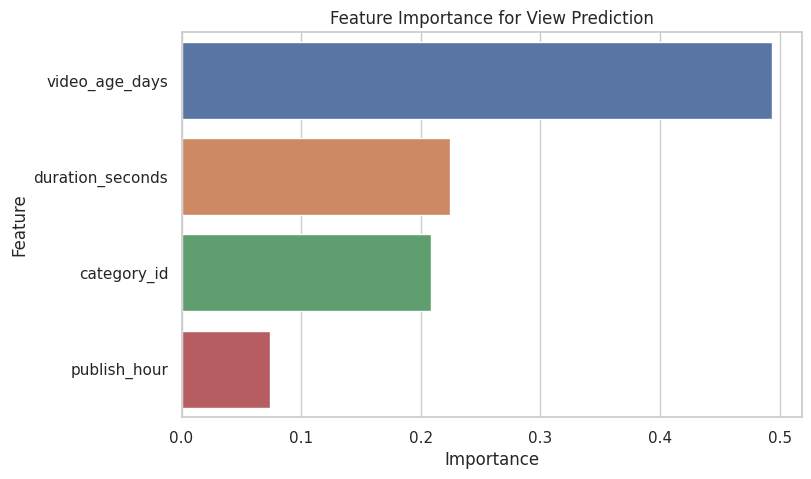

In [13]:
# Prepare Data for Prediction
# We drop columns that are direct consequences of views (like likes, comments) to avoid data leakage if we want to predict 'potential' views.

features = ['duration_seconds', 'video_age_days', 'publish_hour', 'category_id']
target = 'view_count'

# Drop rows with missing values in these columns
model_df = df.dropna(subset=features + [target])

X = model_df[features]
y = np.log1p(model_df[target]) # Log transformation

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (Log Scale): {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

# Feature Importance
importances = model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature')
plt.title('Feature Importance for View Prediction')
plt.show()

***Explanation about the machine learning model:***
* The `text_size` parameter is used in the `train_test_split` function. It determines how the data is split. This tells the algorithm to keep 20% of the total data for the testing phase and use the remaining 80% for training.
* The `random_state` parameter appears in both `train_test_split` and `RandomForestRegressor`. It controls the randomness of the random number generator. By setting this number (42 is a common convention, but it could be any number), we ensure that the data shuffling and model initialization are always the same each time the code is run. This is important for reproducibility. Without it, each time the code is run, the model will use different videos for training and testing, slightly altering the results (the accuracy score will change on its own).
* The `n_estimator` parameter is specific to the RandomForestRegressor model. A random forest is composed of multiple decision trees. `n_estimators` defines the number of trees the forest will create. Here, the model will construct 100 different decision trees. Each tree makes its own prediction about the number of views. Finally, the forest averages the predictions of these 100 trees to give the final result.
* The **Root Mean Squared Error (Log Scale)** measures the average error of our model. The lower this number (closer to 0), the better.
* The **R² Score** is a score out of 1 (or 100%) that tells us how well the model can explain variations in the number of views. Based on the results, our model explains approximately 70% of the variation in views using the provided data (duration, video age, time of publication, category). The remaining 30% is due to factors the model doesn't account for (like thumbnail quality, catchy title, influencer sharing, or pure chance).

## 5. Analyze Factors Contributing to Virality

Viral Threshold: 85,943,840 views
          duration_seconds  engagement_rate  video_age_days
is_viral                                                   
False          5045.609804         0.029313      935.464706
True            215.333333         0.017557      906.370370


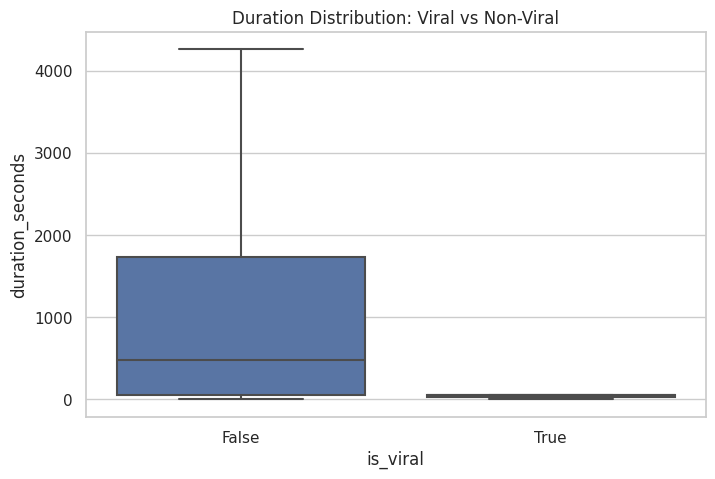

In [14]:
# Define Virality Threshold
viral_threshold = df['view_count'].quantile(0.95)
df['is_viral'] = df['view_count'] > viral_threshold

print(f"Viral Threshold: {viral_threshold:,.0f} views")

# Compare Viral vs Non-Viral
viral_comparison = df.groupby('is_viral')[['duration_seconds', 'engagement_rate', 'video_age_days']].mean()
print(viral_comparison)

# Visualization
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_viral', y='duration_seconds', showfliers=False)
plt.title('Duration Distribution: Viral vs Non-Viral')
plt.show()

***Explanation of the viral threshold:***
* The Viral Threshold is a number that defines the dividing line used by our code to classify a video as "Viral" (True) or "Non-Viral" (False). To do this, the analysis uses the 0.95th percentile of the number of views. This means that only the top 5% of videos with the highest number of views in our dataset are considered "Viral." **In this context, a video is only considered "viral" if it exceeds 85.9 million views.**
* The generated table shows the average values ​​of the three characteristics for the two groups, "Viral" (True) and "Non-Viral" (False). This is where the winning content strategy is revealed.

***Conclusion:***
* **Viral videos last an average of 215 seconds (3 minutes 35 seconds), while non-viral videos last an average of over one hour and twenty minutes.** Therefore, virality is strongly associated with short, impactful formats.
* **Non-viral videos have an engagement rate (`likes` + `comments` / `views`) of 2.93%, which is higher than the 1.76% rate of viral videos.** This is a classic phenomenon with very popular videos. When the number of views reaches 86 million, there are many passive views (people who watch briefly, are not subscribed, or click by chance) that inflate the denominator (views) without proportionally increasing the numerator (`likes` or `comments`). "Normal" videos attract a more dedicated audience that interacts more. "Viral" videos attract everyone, which dilutes the average engagement rate.
* **The average age of the two groups is very similar (around 2.5 years).** Therefore, virality is not limited to recent videos. The important thing is not the age of the video, but its ability to be rediscovered (for example, through search, recommendations, etc.).

## 6. Machine Learning Models for Classification

We will train a classifier to predict if a video will be "High Performance" (above median views).

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79        63
           1       0.72      0.62      0.67        45

    accuracy                           0.74       108
   macro avg       0.74      0.72      0.73       108
weighted avg       0.74      0.74      0.74       108



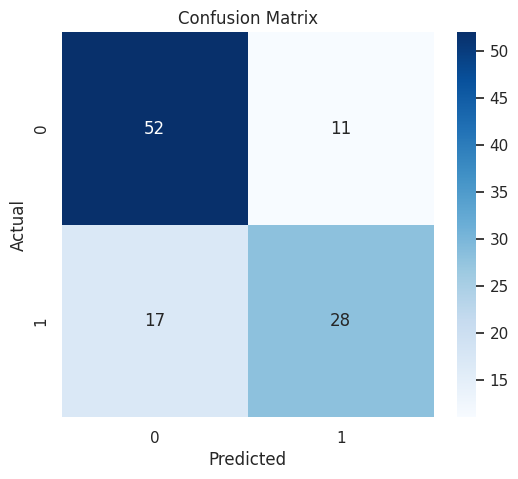

In [15]:
# Define Target Class
median_views = df['view_count'].median()
df['is_high_performance'] = (df['view_count'] > median_views).astype(int)

# Features and Target
X_cls = df[features]
y_cls = df['is_high_performance']

# Split Data
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# Train Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_cls, y_train_cls)

# Evaluate
y_pred_cls = clf.predict(X_test_cls)
print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_cls, y_pred_cls)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The classification report indicates that our model achieves an **overall accuracy of 74%** in distinguishing viral from non-viral videos. However, the analysis shows that **the model is more reliable at identifying non-viral content** (83% recall for class 0) than at detecting true viral hits. Specifically, of all the videos that actually went viral, the model only captured 62% (0.62 recall for class 1). This means that, while 72% of its virality predictions are correct (0.72 accuracy), it misses 38% of future hits because it incorrectly classified them as non-viral, demonstrating that the model is still too conservative in its virality predictions.

## 7. Content Strategy & Optimization

Based on the analysis, here are some strategic recommendations:

1.  **Optimal Duration**: Check the 'Duration vs Engagement' plot. If shorter videos have significantly higher engagement, consider creating more concise content.
2.  **Best Time to Post**: Refer to the 'Average Views by Publish Hour' plot. Schedule videos during peak viewing hours.
3.  **Category Focus**: Identify categories with the highest average views and engagement to target high-potential niches.
4.  **Engagement Drivers**: Focus on increasing likes and comments, as they are strongly correlated with views.